In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, classification_report,recall_score, precision_score
from sklearn.metrics import confusion_matrix   
from scipy import stats
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('train.csv')
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0


In [3]:
df.drop(['id'], axis=1, inplace=True)

In [4]:
df.dtypes

Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

In [5]:
df['Annual_Premium'].unique()

array([ 40454.,  33536.,  38294., ...,  20706., 101664.,  69845.])

In [6]:
df['Age'].unique()

array([44, 76, 47, 21, 29, 24, 23, 56, 32, 41, 71, 37, 25, 42, 60, 65, 49,
       34, 51, 26, 57, 79, 48, 45, 72, 30, 54, 27, 38, 22, 78, 20, 39, 62,
       58, 59, 63, 50, 67, 77, 28, 69, 52, 31, 33, 43, 36, 53, 70, 46, 55,
       40, 61, 75, 64, 35, 66, 68, 74, 73, 84, 83, 81, 80, 82, 85],
      dtype=int64)

In [7]:
df['Vintage'].unique()

array([217, 183,  27, 203,  39, 176, 249,  72,  28,  80,  46, 289, 221,
        15,  58, 147, 256, 299, 158, 102, 116, 177, 232,  60, 180,  49,
        57, 223, 136, 222, 149, 169,  88, 253, 107, 264, 233,  45, 184,
       251, 153, 186,  71,  34,  83,  12, 246, 141, 216, 130, 282,  73,
       171, 283, 295, 165,  30, 218,  22,  36,  79,  81, 100,  63, 242,
       277,  61, 111, 167,  74, 235, 131, 243, 248, 114, 281,  62, 189,
       139, 138, 209, 254, 291,  68,  92,  52,  78, 156, 247, 275,  77,
       181, 229, 166,  16,  23,  31, 293, 219,  50, 155,  66, 260,  19,
       258, 117, 193, 204, 212, 144, 234, 206, 228, 125,  29,  18,  84,
       230,  54, 123, 101,  86,  13, 237,  85,  98,  67, 128,  95,  89,
        99, 208, 134, 135, 268, 284, 119, 226, 105, 142, 207, 272, 263,
        64,  40, 245, 163,  24, 265, 202, 259,  91, 106, 190, 162,  33,
       194, 287, 292,  69, 239, 132, 255, 152, 121, 150, 143, 198, 103,
       127, 285, 214, 151, 199,  56,  59, 215, 104, 238, 120,  2

In [8]:
numerical_columns =df[['Age', 'Annual_Premium', 'Vintage','Policy_Sales_Channel','Region_Code']]    

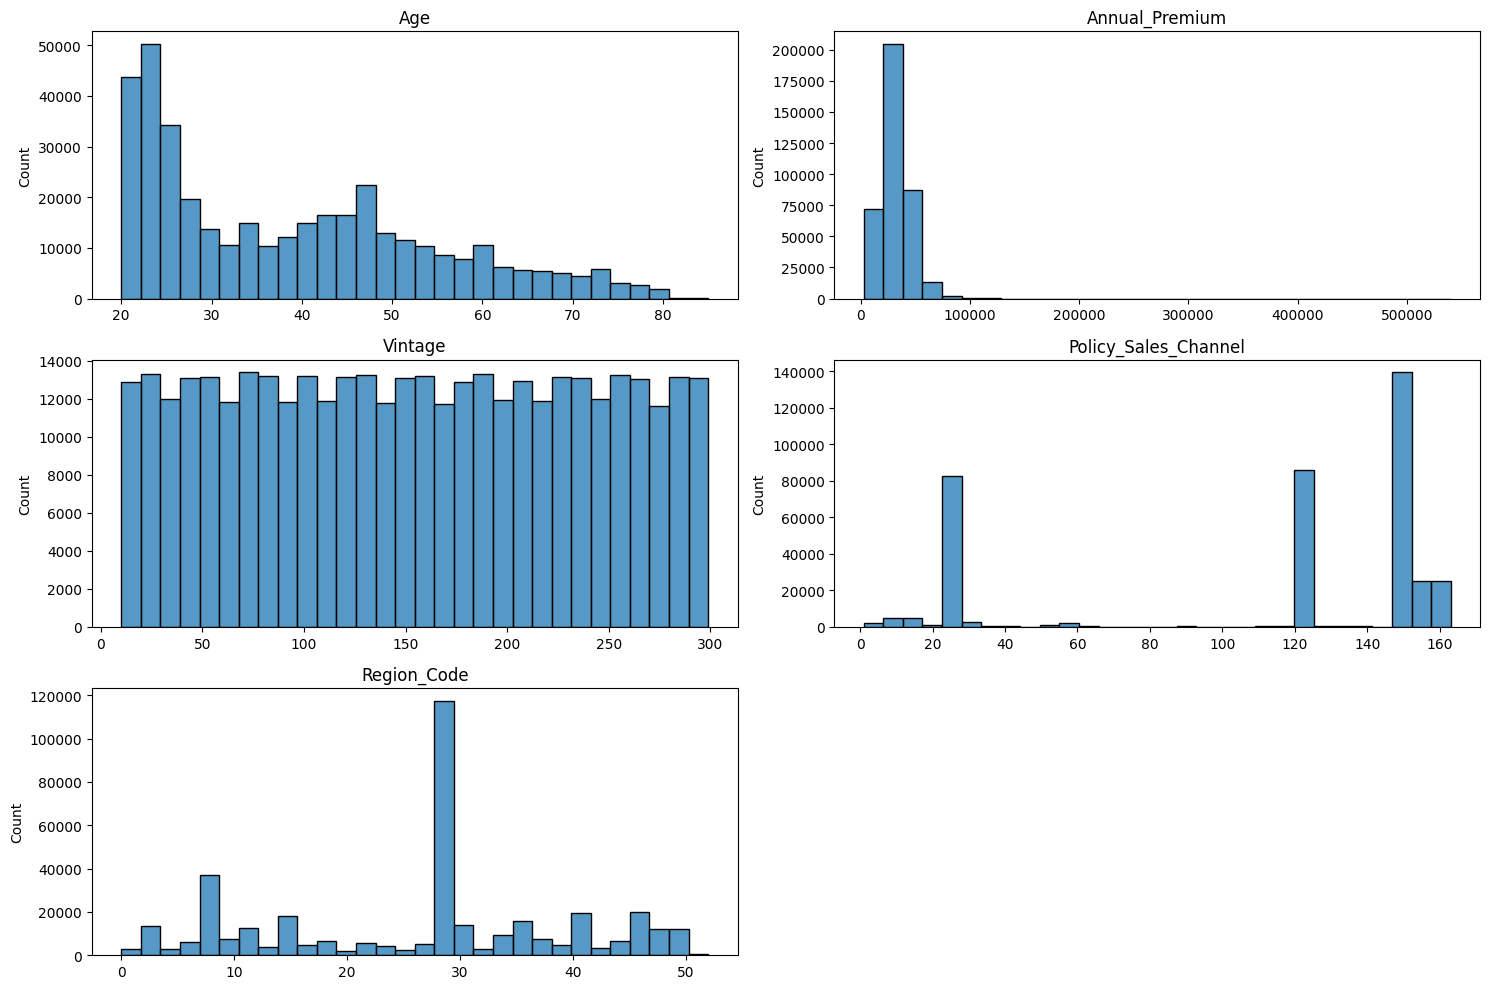

In [9]:
# Plot histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col],bins=30)
    plt.title(col)
    plt.xlabel('')
plt.tight_layout()
plt.show()

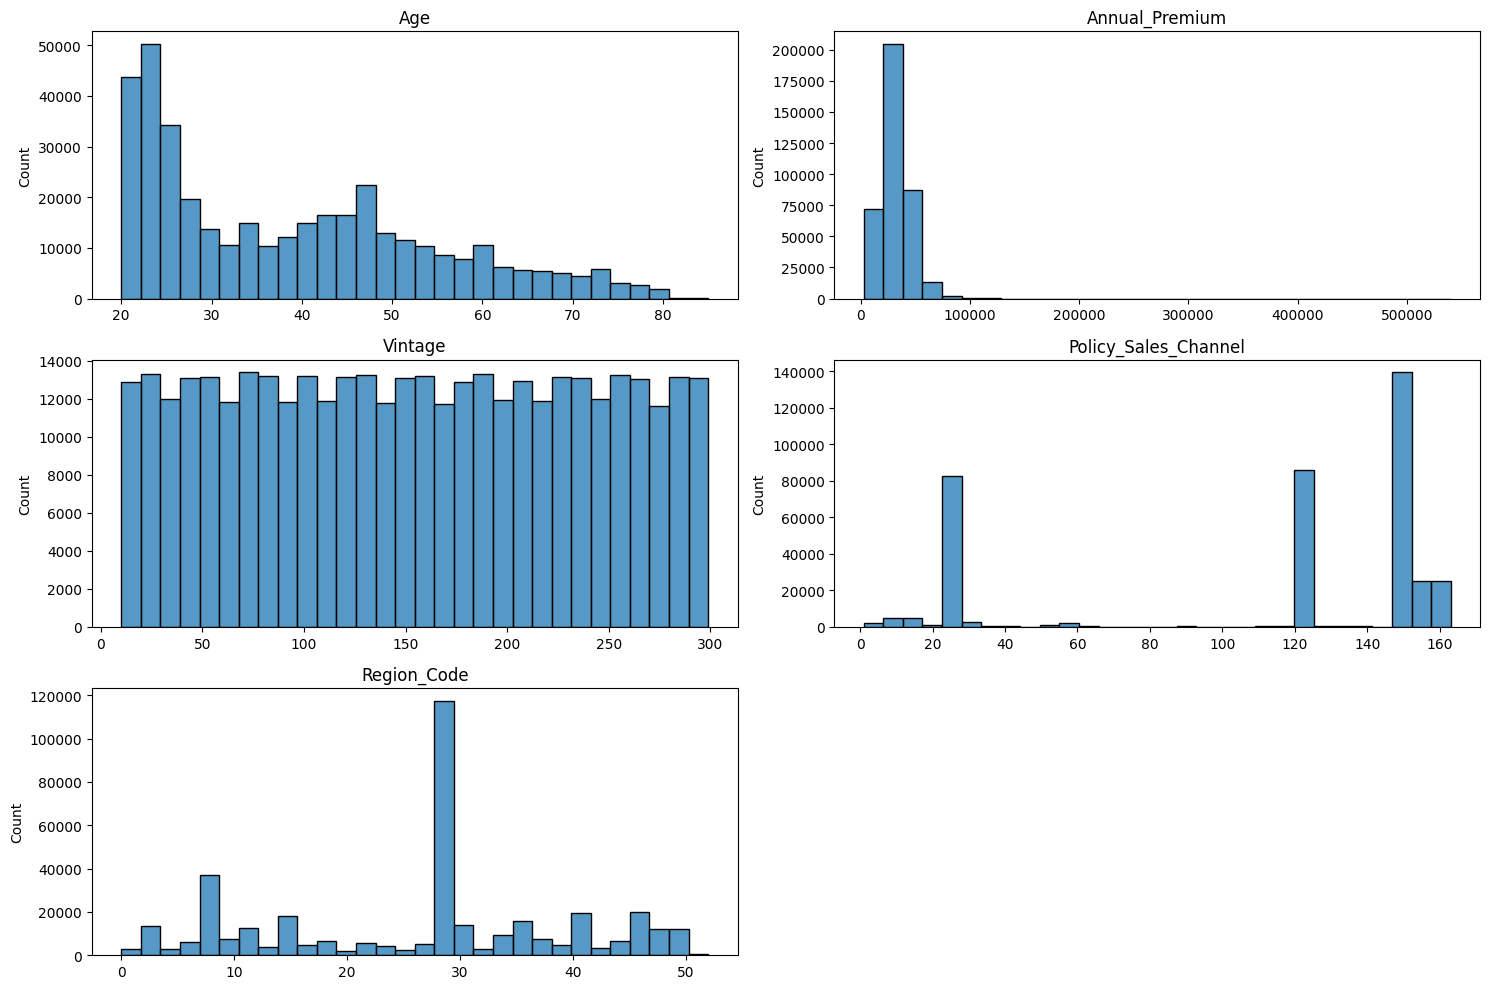

In [10]:
# Plot histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col],bins=30)
    plt.title(col)
    plt.xlabel('')
plt.tight_layout()
plt.show()

In [11]:
#def group_age(age):
#    if 20 <= age <= 40:
#        return '20-40'
#    elif 41 <= age <= 60:
#        return '41-60'
#    elif 61 <= age <= 80:
#        return '61-80'
#    else:
#        return '81-100'

#df['Age'] = df['Age'].apply(group_age)

In [12]:
#def group_vintage(vintage):
#    if 0 <= vintage < 100:
#        return 'Low'
#    elif 100 <= vintage < 200:
#        return 'Medium'
#    else:
#        return 'High'

#df['Vintage'] = df['Vintage'].apply(group_vintage)


In [13]:
c_columns = df[['Gender','Driving_License','Previously_Insured','Vehicle_Age','Vehicle_Damage','Response']]

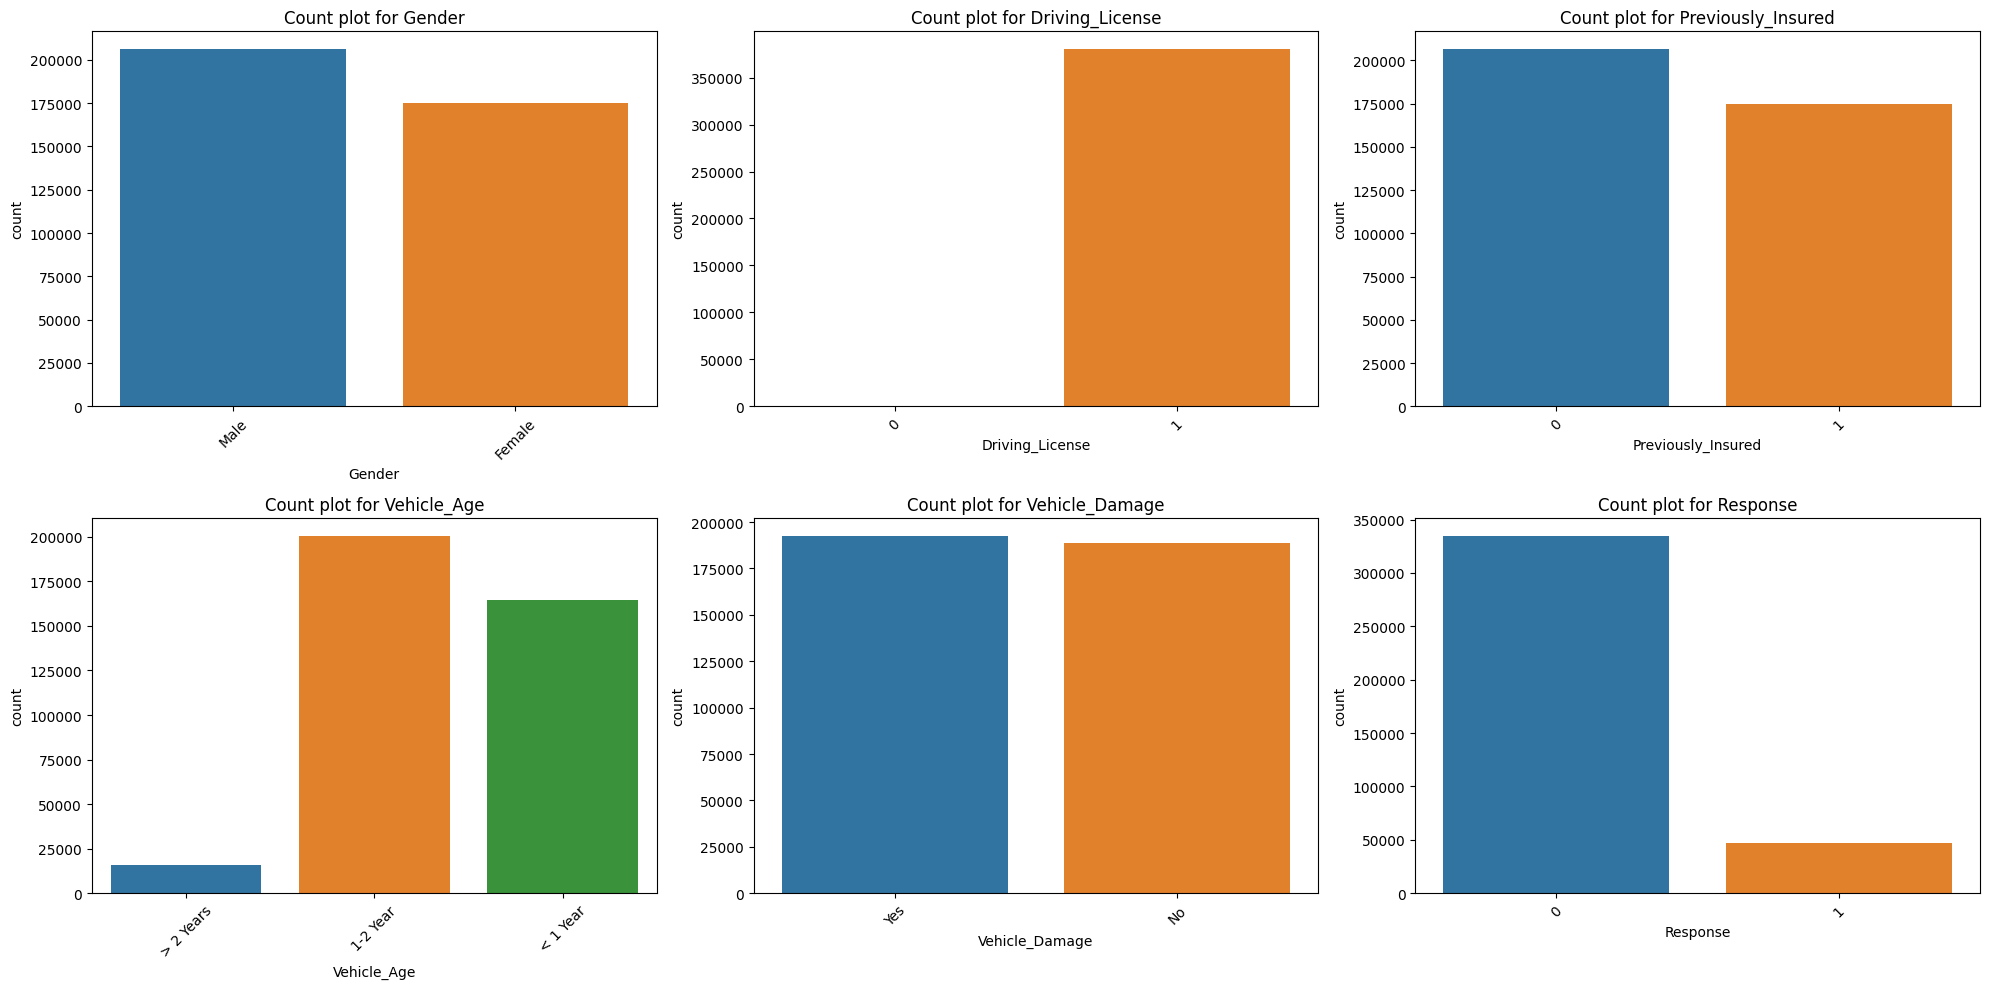

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))  # 2 rows, 4 columns
axes = axes.flatten()  # Flatten the 2D array of axes for easier iteration

# Plot the data for each categorical column
for i, col in enumerate(c_columns):
    sns.countplot(ax=axes[i], x=col, data=df)
    axes[i].set_title(f"Count plot for {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [15]:
df['Vehicle_Age'].unique()

array(['> 2 Years', '1-2 Year', '< 1 Year'], dtype=object)

In [16]:
df['Vehicle_Damage'].unique()

array(['Yes', 'No'], dtype=object)

In [17]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [18]:
df.dtypes

Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

In [19]:
df.isnull().sum()

Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [20]:
df.duplicated().sum()

269

In [21]:
df.drop_duplicates(inplace=True)

Feature Engineering

In [22]:
def encode_vehicle_age(age):
    if age == '< 1 Year':
        return 1
    elif age == '1-2 Year':
        return 2
    elif age == '> 2 Years':
        return 3
    else:
        return 0  

df['Vehicle_Age'] = df['Vehicle_Age'].apply(encode_vehicle_age)
df['Vehicle_Age'].unique()

array([3, 2, 1], dtype=int64)

In [23]:
df['Vehicle_Damage'] = df['Vehicle_Damage'].map({'Yes': 1, 'No': 0})
df['Vehicle_Damage'].unique()

array([1, 0], dtype=int64)

In [24]:
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})
df['Gender'].unique()

array([1, 0], dtype=int64)

In [25]:
#def encode_vintage(vintage):
  #  if vintage == 'Low':
  #      return 1
  #  elif vintage == 'Medium':
  #      return 2
  #  elif vintage == 'High':
  #      return 3
  #  else:
  #      return 0

#df['Vintage'] = df['Vintage'].apply(encode_vintage)
#df['Vintage'].unique()

In [26]:
#def encode_age(age):
#    if age == '20-40':
 #       return 1
  #  elif age == '41-60':
   #     return 2
    #elif age == '61-80':
     #   return 3
    #elif age == '81-100':
     #   return 4
    #else:
     #   return 0

#df['Age'] = df['Age'].apply(encode_age)
#df['Age'].unique()

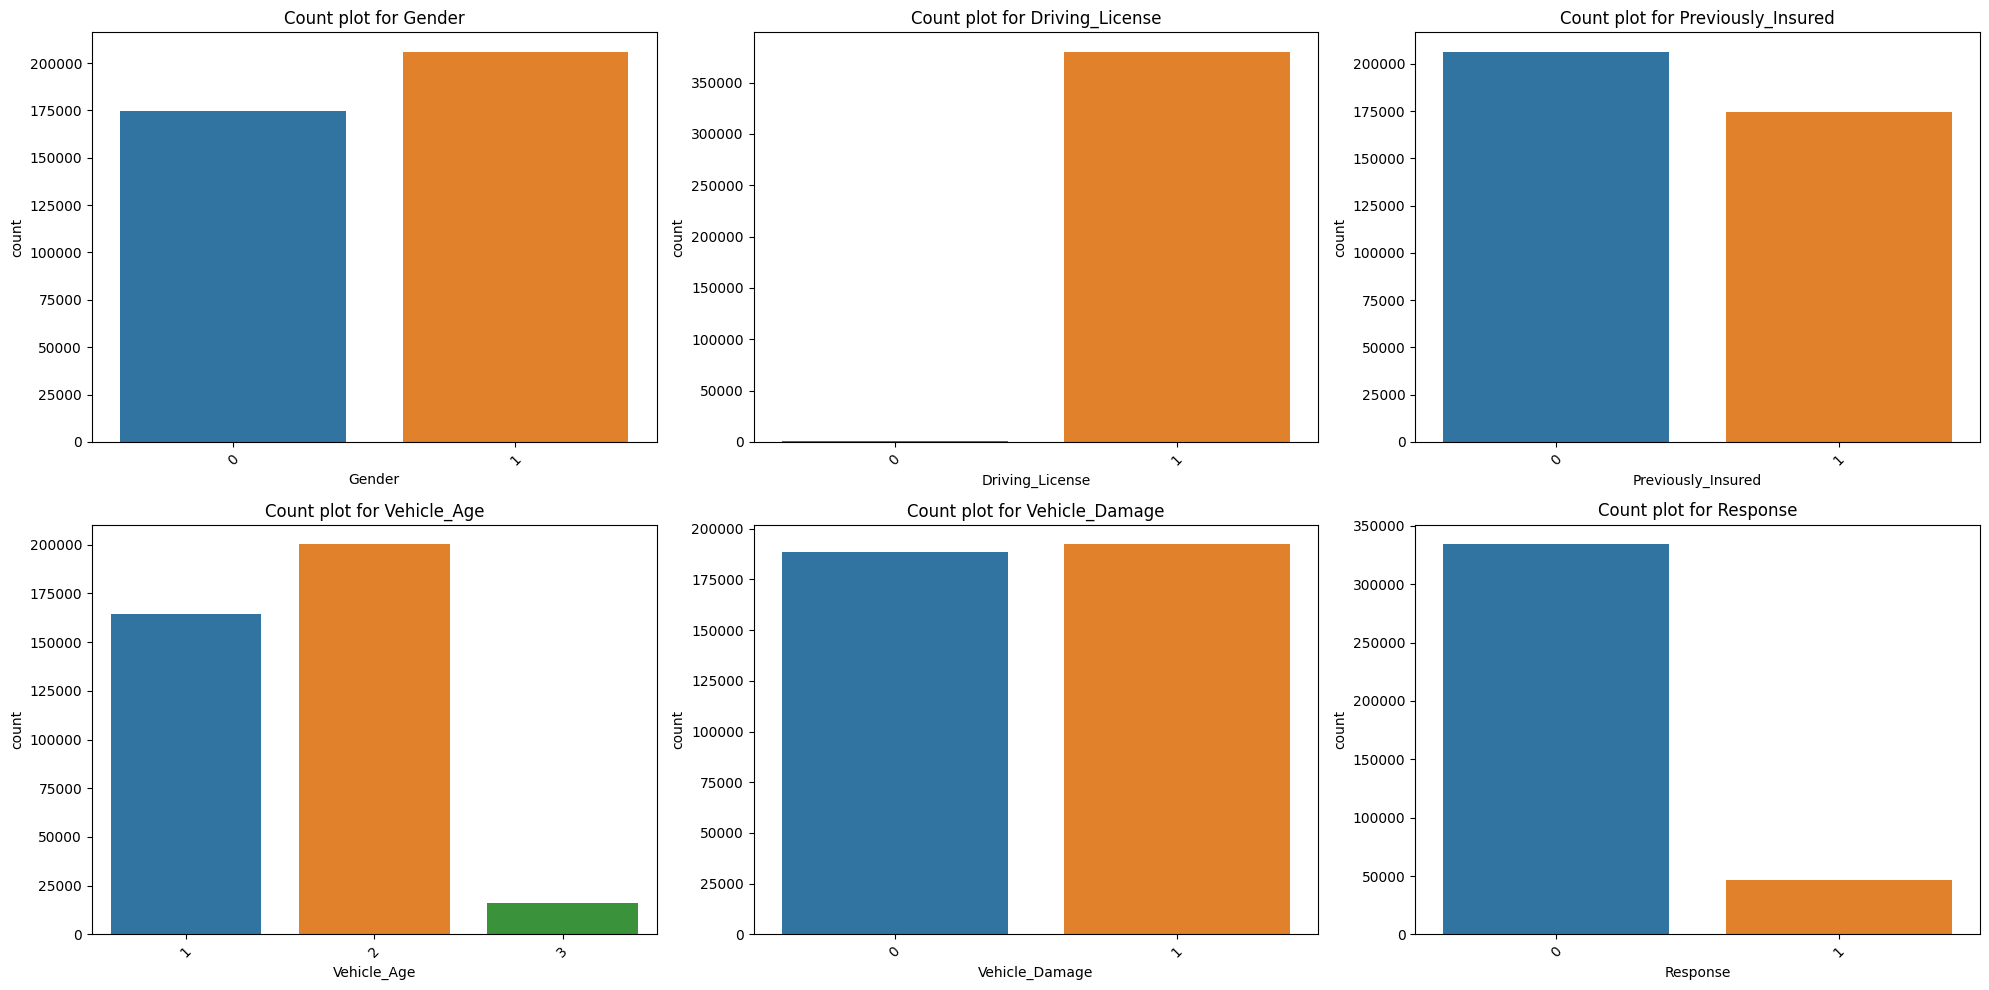

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))  # 2 rows, 4 columns
axes = axes.flatten()  # Flatten the 2D array of axes for easier iteration

# Plot the data for each categorical column
for i, col in enumerate(c_columns):
    sns.countplot(ax=axes[i], x=col, data=df)
    axes[i].set_title(f"Count plot for {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [28]:
df.dtypes

Gender                    int64
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age               int64
Vehicle_Damage            int64
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

In [29]:
df.corr()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
Gender,1.000000,0.145577,-0.018382,0.000561,-0.081899,0.160434,0.091579,0.003731,-0.111209,-0.002465,0.052476
Age,0.145577,1.000000,-0.079799,0.042545,-0.254666,0.765765,0.267499,0.067478,-0.577798,-0.001278,0.111098
Driving_License,-0.018382,-0.079799,1.000000,-0.001083,0.014975,-0.037316,-0.016628,-0.011865,0.043741,-0.000850,0.010161
Region_Code,0.000561,0.042545,-0.001083,1.000000,-0.024652,0.043766,0.028239,-0.010540,-0.042378,-0.002737,0.010584
Previously_Insured,-0.081899,-0.254666,0.014975,-0.024652,1.000000,-0.380834,-0.824064,0.004286,0.219382,0.002623,-0.341201
Vehicle_Age,0.160434,0.765765,-0.037316,0.043766,-0.380834,1.000000,0.396814,0.041590,-0.550643,-0.001920,0.221829
Vehicle_Damage,0.091579,0.267499,-0.016628,0.028239,-0.824064,0.396814,1.000000,0.009357,-0.224376,-0.002116,0.354426
Annual_Premium,0.003731,0.067478,-0.011865,-0.010540,0.004286,0.041590,0.009357,1.000000,-0.113256,-0.000547,0.022482
Policy_Sales_Channel,-0.111209,-0.577798,0.043741,-0.042378,0.219382,-0.550643,-0.224376,-0.113256,1.000000,0.000046,-0.139010
Vintage,-0.002465,-0.001278,-0.000850,-0.002737,0.002623,-0.001920,-0.002116,-0.000547,0.000046,1.000000,-0.001036


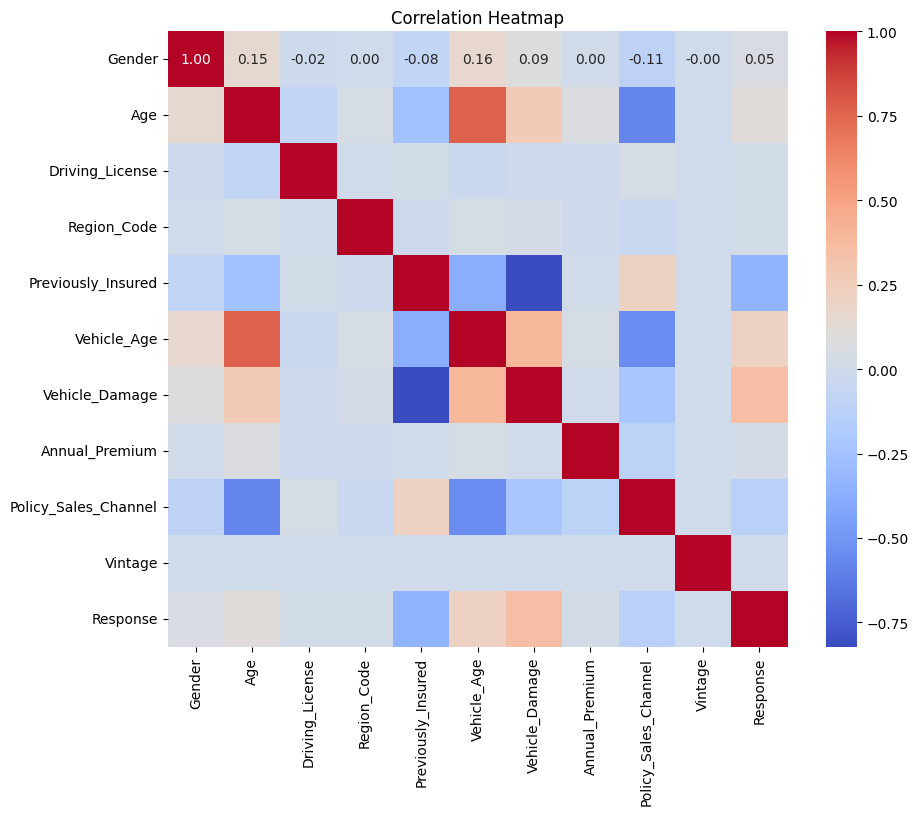

In [30]:
correlation_matrix = df.corr()

plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [31]:
df['Driving_License'].value_counts()

Driving_License
1    380028
0       812
Name: count, dtype: int64

In [32]:
#df =pd.get_dummies(df, columns =['Vehicle_Age'],dtype=int)

**MODEL TRAINING**

In [33]:
X=df.drop('Response', axis=1)
y=df['Response']

In [34]:
scaler = StandardScaler()
X[['Age', 'Annual_Premium', 'Vintage', 'Policy_Sales_Channel','Region_Code']] = scaler.fit_transform(X[['Age', 'Annual_Premium', 'Vintage', 'Policy_Sales_Channel','Region_Code']])

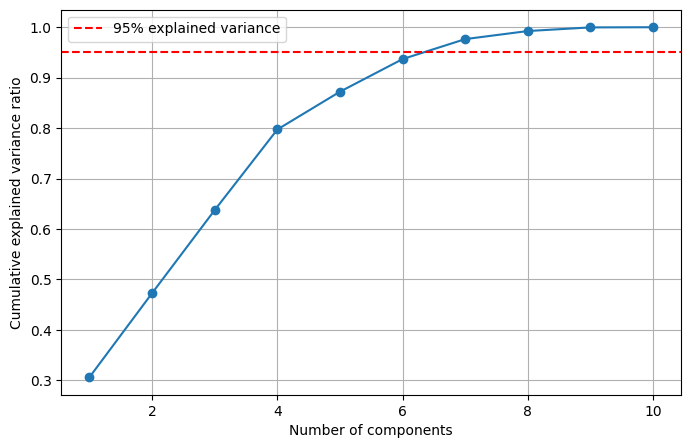

Number of components for 95% explained variance: 7


In [ ]:
# Fitting PCA to the data
pca = PCA()
X_pca = pca.fit(X)  

# Cumulative explained variance ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot of the explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% explained variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance ratio')
plt.legend()
plt.grid()
plt.show()

# Selecting the number of components for 95% variance
n_components = np.argmax(explained_variance >= 0.95) + 1
print(f"Number of components for 95% explained variance: {n_components}")


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [41]:
# Initialization with 7 components
pca = PCA(n_components=7)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)

X_train_pca shape: (266588, 7)
X_test_pca shape: (114252, 7)


In [42]:
# Initialize SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.55)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)

# Display the sizes of the original and resampled datasets
print(f'Original dataset shape: {X_train.shape}')
print(f'Resampled dataset shape: {X_train_resampled.shape}')


Original dataset shape: (266588, 10)
Resampled dataset shape: (362410, 7)


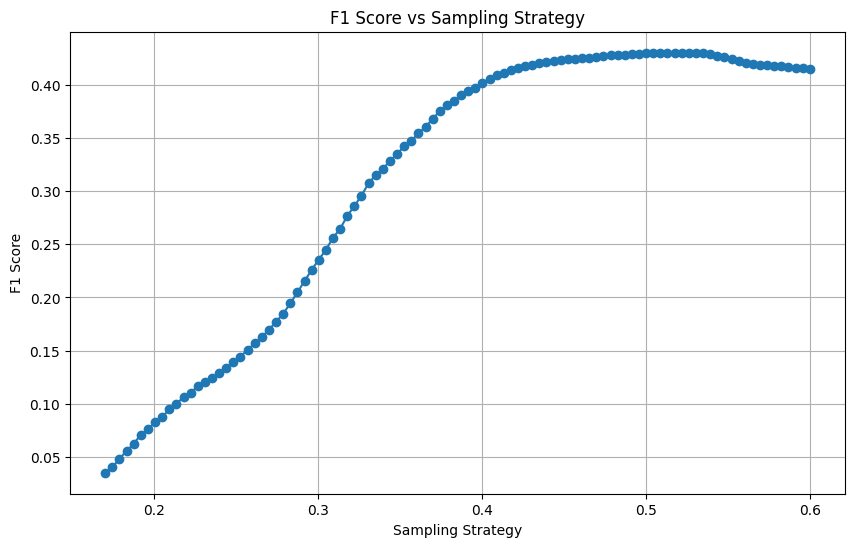

In [43]:
# List of different sampling_strategy values
sampling_strategies = np.linspace(0.17, 0.6, 100)

# List to store F1 score results
f1_scores = []

# Running experiments for different sampling_strategy values
for strategy in sampling_strategies:
    smote = SMOTE(random_state=42, sampling_strategy=strategy)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)
    
    model = LogisticRegression(random_state=42)
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_pca)
    
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(sampling_strategies, f1_scores, marker='o')
plt.xlabel('Sampling Strategy')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Sampling Strategy')
plt.grid(True)
plt.show()

In [44]:
y_train_resampled.value_counts()

Response
0    233813
1    140287
Name: count, dtype: int64

In [45]:
X_train_resampled.shape, X_test_pca.shape

((374100, 7), (114252, 7))

**LOGISTIC REGRESSION**

In [46]:
model = LogisticRegression(random_state=42)
model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test_pca)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Recall',recall_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))   
print('\nClassification Report:\n', classification_report(y_test, y_pred))



Accuracy: 0.7054143472324336
Recall 0.8585190510424155
Precision: 0.27370447617519655
F1 Score: 0.41507794442223805

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.68      0.80    100342
           1       0.27      0.86      0.42     13910

    accuracy                           0.71    114252
   macro avg       0.62      0.77      0.61    114252
weighted avg       0.89      0.71      0.76    114252



**Weighted Logistic Regression**

In [47]:
model = LogisticRegression(random_state=42,class_weight={0:1.35,1:1}) #Weighted Logistic Regression
model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test_pca)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Recall',recall_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))   
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.7797587788397577
Recall 0.6631919482386772
Precision: 0.3105746894253106
F1 Score: 0.4230390021323917

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86    100342
           1       0.31      0.66      0.42     13910

    accuracy                           0.78    114252
   macro avg       0.63      0.73      0.64    114252
weighted avg       0.87      0.78      0.81    114252



**Random Forest**

In [48]:
# Initialize the RandomForestClassifier model
rfc_model = RandomForestClassifier(n_jobs=-1, random_state=42)

# Train the model on the training data
rfc_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rfc = rfc_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_rfc))
print('Recall:', recall_score(y_test, y_pred_rfc))
print('Precision:', precision_score(y_test, y_pred_rfc))
print('F1 Score:', f1_score(y_test, y_pred_rfc))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rfc))

Accuracy: 0.8671620628085285
Recall: 0.11912293314162473
Precision: 0.3617114167212399
F1 Score: 0.1792223243740198

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93    100342
           1       0.36      0.12      0.18     13910

    accuracy                           0.87    114252
   macro avg       0.62      0.54      0.55    114252
weighted avg       0.82      0.87      0.84    114252



**Random Forest Classifier with Oversampling(SMOTE) and Principal Componenets Analysis(PCA)**

In [49]:
# Initialize the RandomForestClassifier model
rfc_model = RandomForestClassifier(n_jobs=-1, random_state=42)

# Train the model on the resampled training data
rfc_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_rfc = rfc_model.predict(X_test_pca)

print('Accuracy:', accuracy_score(y_test, y_pred_rfc))
print('Recall:', recall_score(y_test, y_pred_rfc))
print('Precision:', precision_score(y_test, y_pred_rfc))
print('F1 Score:', f1_score(y_test, y_pred_rfc))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rfc))


Accuracy: 0.8133949515106956
Recall: 0.4502516175413372
Precision: 0.31415529695024075
F1 Score: 0.3700880458547539

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89    100342
           1       0.31      0.45      0.37     13910

    accuracy                           0.81    114252
   macro avg       0.62      0.66      0.63    114252
weighted avg       0.85      0.81      0.83    114252



**DECISION TREE CLASIFFIER**

In [50]:
# Initialize the DecisionTreeClassifier model
cart_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
cart_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_cart = cart_model.predict(X_test)

# Display evaluation metrics
print('Accuracy:', accuracy_score(y_test, y_pred_cart))
print('Recall:', recall_score(y_test, y_pred_cart))
print('Precision:', precision_score(y_test, y_pred_cart))
print('F1 Score:', f1_score(y_test, y_pred_cart))
print('\nClassification Report:\n', classification_report(y_test, y_pred_cart))

Accuracy: 0.8230315443055701
Recall: 0.312508986340762
Precision: 0.2897420515896821
F1 Score: 0.30069518901532183

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.90    100342
           1       0.29      0.31      0.30     13910

    accuracy                           0.82    114252
   macro avg       0.60      0.60      0.60    114252
weighted avg       0.83      0.82      0.83    114252



**DECISION TREE CLASSIFIER WITH SMOTE AND PCA**

In [51]:
# Initialize the DecisionTreeClassifier model
cart_model = DecisionTreeClassifier(random_state=42)

# Train the model on the resampled training data
cart_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_cart = cart_model.predict(X_test_pca)

# Display evaluation metrics
print('Accuracy:', accuracy_score(y_test, y_pred_cart))
print('Recall:', recall_score(y_test, y_pred_cart))
print('Precision:', precision_score(y_test, y_pred_cart))
print('F1 Score:', f1_score(y_test, y_pred_cart))
print('\nClassification Report:\n', classification_report(y_test, y_pred_cart))


Accuracy: 0.7955484367888527
Recall: 0.4292595255212078
Precision: 0.27913608526950584
F1 Score: 0.33829069998017053

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88    100342
           1       0.28      0.43      0.34     13910

    accuracy                           0.80    114252
   macro avg       0.60      0.64      0.61    114252
weighted avg       0.84      0.80      0.81    114252



**XGBoost**

In [52]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report

# Initialize the XGBClassifier model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train the model on the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Display evaluation metrics
print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('F1 Score:', f1_score(y_test, y_pred_xgb))
print('\nClassification Report:\n', classification_report(y_test, y_pred_xgb))


Accuracy: 0.8770524804817421
Recall: 0.03306973400431344
Precision: 0.43519394512771997
F1 Score: 0.06146856417451727

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93    100342
           1       0.44      0.03      0.06     13910

    accuracy                           0.88    114252
   macro avg       0.66      0.51      0.50    114252
weighted avg       0.83      0.88      0.83    114252



**XGBOOST with SMOTE and PCA**

In [53]:
# Initialize the XGBClassifier model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train the model on the resampled training data
xgb_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_pca)

# Display evaluation metrics
print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('F1 Score:', f1_score(y_test, y_pred_xgb))
print('\nClassification Report:\n', classification_report(y_test, y_pred_xgb))


Accuracy: 0.7546301158841858
Recall: 0.802372393961179
Precision: 0.30623388026120835
F1 Score: 0.4432838192072444

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.75      0.84    100342
           1       0.31      0.80      0.44     13910

    accuracy                           0.75    114252
   macro avg       0.64      0.78      0.64    114252
weighted avg       0.88      0.75      0.79    114252



**XGBOOST WITH HIPERPARAMETER TUNING**

In [54]:
# Initialize the XGBClassifier model with optimized hyperparameters
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    learning_rate=0.05,        # Reduced learning rate for better precision
    n_estimators=300,          # Increased number of trees
    max_depth=6,               # Moderate tree depth
    subsample=0.8,             # 80% of the dataset used for each tree
    colsample_bytree=0.8       # 80% of features used for each tree
)

# Train the model on the resampled training data
xgb_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_pca)

# Display evaluation metrics
print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('F1 Score:', f1_score(y_test, y_pred_xgb))
print('\nClassification Report:\n', classification_report(y_test, y_pred_xgb))


Accuracy: 0.7498949690158597
Recall: 0.8227174694464414
Precision: 0.30474263041567917
F1 Score: 0.444746711229427

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.74      0.84    100342
           1       0.30      0.82      0.44     13910

    accuracy                           0.75    114252
   macro avg       0.64      0.78      0.64    114252
weighted avg       0.89      0.75      0.79    114252

